In [1]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

from util import *

In [2]:
def _planck(t, eps=1.0):
    sigma = 5.67e-8
    return eps * sigma * t**4

In [3]:
models = list_models()
models

['proteus', 'pacman', 'moai', 'lincs', 'gooey', 'neongooey']

In [4]:
models_data = {}
for m in models:
    models_data[m] = load_model_data(m, quiet=True)

Loading model proteus
Loading model pacman
Loading model moai
Loading model lincs
Loading model gooey
Loading model neongooey


In [5]:
planets = list_planets()
planets

('earth', 'venus')

In [6]:
print(", ".join(models_data["proteus"]["earth"]["Hhigh-Chigh-evo"].keys()))

t(yr), T_surf(K), T_pot(K), flux_surf(W/m2), flux_OLR(W/m2), flux_ASR(W/m2), phi(vol_frac), fO2_melt(bar), fO2_solid(bar), thick_surf_bl(m), massC_solid(kg), massC_melt(kg), massC_atm(kg), massH_solid(kg), massH_melt(kg), massH_atm(kg), massO_atm(kg), p_surf(bar), p_H2O(bar), p_CO2(bar), p_CO(bar), p_H2(bar), p_CH4(bar), p_O2(bar), mmw(kg/mol), R_trans(m), R_solid(m), viscosity(Pa.s), phi(mass_frac), p_SO2(bar), p_NH3(bar), p_N2(bar), p_H2S(bar), p_S2(bar)


## Tsurf vs Phi

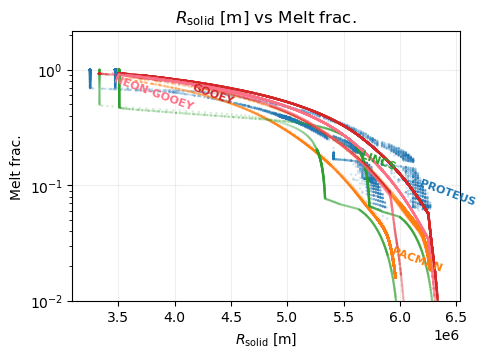

In [7]:
fig,ax = plt.subplots(1,1, figsize=(5,3.5))

# scatter = True
# xkey = "viscosity(Pa.s)"
# xlog = True

# scatter = False
# xkey = "T_surf(K)"
# xlog = False

scatter = True
xkey = "R_solid(m)"
xlog = False

dx = 0.01

ykey = "phi(vol_frac)"

for im,m in enumerate(models):
    c = get_color(m)

    x = []
    y = []
    for p in planets:
        for case,v in models_data[m][p].items():
            if "-evo" not in case:
                continue
            x.extend(v[xkey].values)
            y.extend(v[ykey].values)

    # sort data
    mask = np.argsort(x)
    x = np.array(x)[mask]
    y = np.array(y)[mask]

    if len(np.unique(x)) == 1:
        continue

    if scatter:
        ax.scatter(x, y, color=c, ec='none', s=3, alpha=0.2, zorder=8)

    # convert to filled region
    else:
        if xlog:
            xx = np.logspace(np.log10(min(x)), np.log10(max(x)), 100)
        else:
            xx = np.linspace(min(x), max(x), 100)
        ytop, ybot = [], []
        for i in range(len(xx)):
            mask = np.argwhere(abs(x-xx[i])/xx[i]<=dx).flatten()
            if len(mask) == 0:
                ytop.append(np.nan)
                ybot.append(np.nan)
            else:   
                ytop.append(np.amax(y[mask]))
                ybot.append(np.amin(y[mask]))

        ax.fill_between(xx, ybot, ytop, color=c, alpha=0.5, zorder=10)

    l = get_label(m)
    i = np.argmin(np.abs(y-np.percentile(y,(1+im)*100/len(models))))
    ax.text(x[i], y[i], l, color=c, fontsize=8, ha='left', va='top', rotation=-20, zorder=30, weight='bold')

ax.grid(alpha=0.2, zorder=0)
ax.set_xlabel(get_label(xkey))
ax.set_ylabel(get_label(ykey))
if xlog:
    ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(bottom=0.01)

title = get_label(xkey) + " vs " + get_label(ykey)
ax.set_title(title)

plt.show()

## Temperature over time

In [8]:
t_ini = 50e6 # years

ages_Ga = {
    "CAI":              4.57,
    "Earth formed":     4.54,
    "Moon formed":      4.34,
    "MO early":         4.33,
    "MO late" :         4.20,
    "GOE early":        2.5,
    "GOE late" :        2.2,
}

ages_yr = {k: (ages_Ga["CAI"] - v ) * 1e9 - t_ini for k, v in ages_Ga.items()}

proteus
pacman
moai
lincs
gooey
neongooey


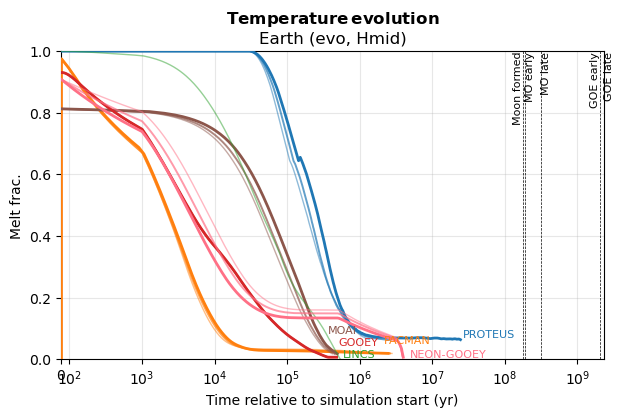

In [9]:
fig,ax = plt.subplots(1,1, figsize=(7,4))

xkey = "t(yr)"
ykey = "phi(vol_frac)"
planet = "earth"

controls = ["evo", "Hmid"]

txts = []

ymax = 1
ymin = 0
for m in models:
    print(m)
    d = models_data[m][planet]
    col = get_color(m)
    lbl = get_label(m)

    for case in d.keys():
        if np.all([c in case for c in controls]):

            if "Chigh" in case:
                sf = 1.0
            elif "Cmid" in case:
                sf = 0.7
            else:
                sf = 0.5


            x = d[case][xkey] 
            y = d[case][ykey]
            ax.plot(x, y, label=lbl, color=col, lw=sf*2, alpha=sf*1, zorder=4)

            if lbl != "":
                l = ax.text(x.iloc[-1], y.iloc[-1], lbl, color=col, fontsize=8, zorder=5)
                txts.append(l)

            lbl = ""
            # ymax = max(ymax, np.max(y))
            ymin = min(ymin, np.min(y))


# add vertical lines for ages of interest
for k, x in ages_yr.items():
    ax.axvline(x, color="k", ls="--", lw=0.5, zorder=6)
    va = 'top'
    if k in ["Moon formed", "GOE early"]:
        va = 'bottom'
    ax.annotate(k, xy=(x, ymax), ha="right", va=va, fontsize=8, rotation=90, rotation_mode='anchor')

ax.axvline(x=0, color="k", ls="-", lw=0.5)

ax.set_xscale("symlog", linthresh=1e3)
ax.set_xlabel("Time relative to simulation start (yr)")
ax.set_xlim(left=0, right=ages_yr["GOE late"])

ax.set_ylabel(get_label(ykey))
ax.set_ylim(ymin, ymax)

ax.grid(alpha=0.3, zorder=-2)

# legend of models
# ax.legend(loc='upper left', bbox_to_anchor=(0, -0.2), ncols=4, frameon=False, handletextpad=0.5)

title = r"$\bf Temperature\,evolution$" + "\n" + get_label(planet) + f" ({', '.join(controls)})"
ax.set_title(title)

adjust_text(txts)


plt.show()

proteus
pacman
moai
lincs
gooey
neongooey


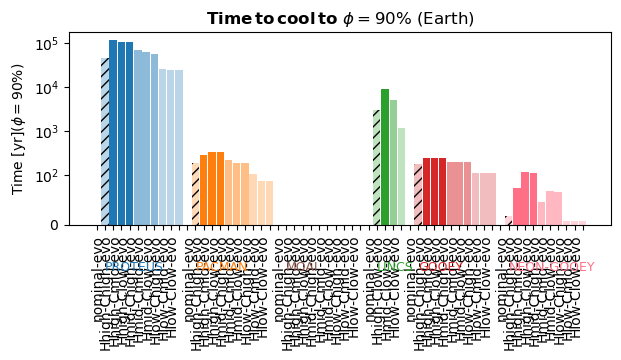

In [ ]:
def plot_cooling_time_bars(phi):

    fig, ax = plt.subplots(1,1, figsize=(7,2.5))

    ykey = "t(yr)"

    xlbl  = []
    xlocs = []
    ymax = 1e3
    for m in models:
        print(m)
        d = models_data[m]["earth"]
        col = get_color(m)
        lbl = get_label(m)

        # spacer
        ax.bar(m,0)
        xlocs.append(m)
        xlbl.append("")
        
        xlbl_this = None
        for case in d.keys():
            if "evo" in case:

                if "Hhigh" in case:
                    sf = 1.0
                elif "Hmid" in case:
                    sf = 0.5
                else:
                    sf = 0.3

                anno = case.split("-")[0]

                idx = np.argmin(np.abs(d[case]["phi(vol_frac)"] - phi))
                y = d[case][ykey].iloc[idx]

                x = m + case
                c = get_color(m)
                a = sf

                if xlbl_this is None:
                    xlbl_this = x

                hatch = ''
                if "nominal" in case:
                    hatch = '///'

                ax.bar(x, y, color=c, alpha=a, width=0.9, hatch=hatch)
                xlocs.append(x)

                ymax = max(ymax, y)

                x = case
                xlbl.append(x)

        ax.text(xlbl_this, -1e2, lbl, ha="left", va="bottom", fontsize=9, color=col, rotation_mode="anchor")
        
    i = 0
    for k, y in ages_yr.items():
        i += 1
        va = 'top'
        if k in ["Moon formed", "GOE early", "MO late"]:
            va = 'bottom'
        if y > ymax:
            continue
        ax.axhline(y, color="k", ls="--", lw=0.5, zorder=6)
        ax.annotate(k, xy=(xlocs[i*4], y), ha="left", va=va, fontsize=8)


    ax.set_ylabel(get_label(ykey) + r"($\phi=$" + f"{phi*100:.0f}%)")
    ax.set_yscale("symlog", linthresh=1e2)
    ax.set_ylim(bottom=0, top=ymax*1.5)


    # show ticks on top panel and hide bottom
    ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
    ax.set_xticks(xlocs,xlbl, fontsize=10, rotation=90, ha='right')

    fig.align_ylabels()

    title = r"${\bf Time\,to\,cool\,to}\,\,\phi=$" + f"{phi*100:.0f}%" + " (" + get_label(planet) + ")"
    ax.set_title(title)

    fig.subplots_adjust(hspace=0.27)

    plt.show()

plot_cooling_time_bars(0.9)

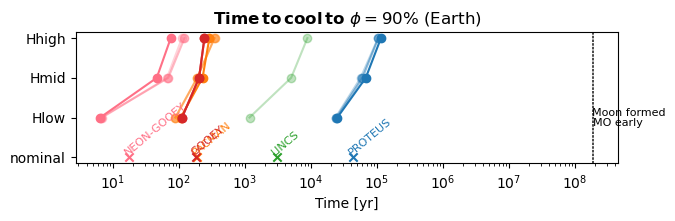

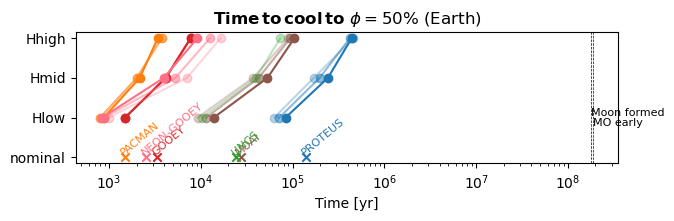

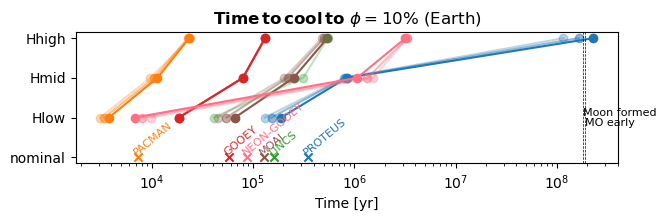

In [53]:
def plot_cooling_time(phi):
    fig, ax = plt.subplots(1,1, figsize=(7,1.7))

    xkey = "t(yr)"
    ykey = "p_surf(bar)"

    xmax = 3e8
    for m in models:
        d = models_data[m]["earth"]
        col = get_color(m)
        lbl = get_label(m)

        # nominal case
        idx = np.argmin(np.abs(d["nominal-evo"]["phi(vol_frac)"] - phi))
        row = d["nominal-evo"].iloc[idx]

        x,y = row[xkey], row[ykey]
        y = "nominal"
        ax.scatter(x, y, color=col, marker='x', zorder=5)
        ax.annotate(lbl, xy=(x, y), color=col, fontsize=8, ha='left', va='bottom', zorder=5, rotation=40, rotation_mode='anchor')

        for case_c in ["Chigh", "Cmid", "Clow"]:

            xplt = []
            yplt = []

            for case_h in ["Hlow", "Hmid", "Hhigh"]:            
                case = f"{case_h}-{case_c}-evo"
                if case not in d:
                    continue

                if "high" in case_c:
                    sf = 1.0
                elif "mid" in case_c:
                    sf = 0.5
                else:
                    sf = 0.3

                idx = np.argmin(np.abs(d[case]["phi(vol_frac)"] - phi))
                row = d[case].iloc[idx]
                xplt.append(row[xkey])
                yplt.append(case_h)

            if len(xplt) == 0:
                continue
            ax.plot(xplt, yplt, color=col, alpha=sf*1, zorder=4, marker='o')

            xmax = max(xmax, np.amax(xplt))

        
    i = 0
    for k, x in ages_yr.items():
        i += 1
        va = 'top'
        if k in ["Moon formed", "GOE early", "MO late"]:
            va = 'bottom'
        if x > xmax:
            continue
        ax.axvline(x, color="k", ls="--", lw=0.5, zorder=6)
        ax.annotate(k, xy=(x, "Hlow"), ha="left", va=va, fontsize=8)

    # ax.legend()
    ax.set_xscale("log")
    ax.set_xlabel(get_label(xkey))

    title = r"${\bf Time\,to\,cool\,to}\,\,\phi=$" + f"{phi*100:.0f}%" + " (" + get_label(planet) + ")"
    ax.set_title(title)

    plt.show()

plot_cooling_time(0.9)
plot_cooling_time(0.5)
plot_cooling_time(0.1)

## Cooling rate as a function of temperature

proteus
pacman
moai
lincs
gooey
neongooey


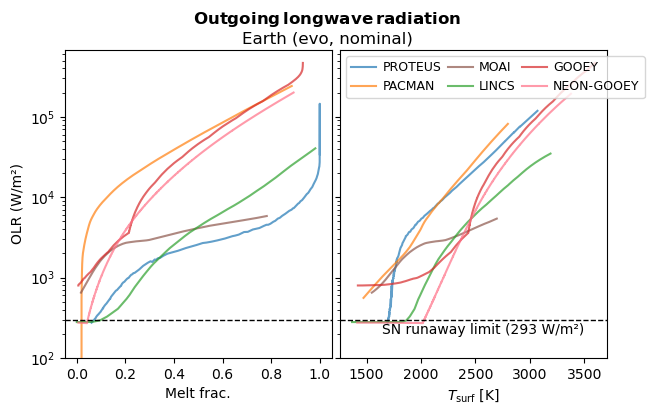

In [12]:
fig,axs = plt.subplots(1,2, figsize=(7,4), sharey=True)
axl, axr = axs

controls = ["evo", "nominal"]
xkeys = ["phi(vol_frac)", "T_surf(K)"]

for m in models:
    print(m)
    d = models_data[m]["earth"]
    col = get_color(m)
    lbl = get_label(m)

    for case in d.keys():
        if np.all([param in case for param in controls]):

            # idx = np.argmin(np.abs(d[case]["phi(vol_frac)"] - phi_compare))
            row = d[case]#.iloc[idx]

            col = get_color(m)
            al = 0.7

            for (ax,xkey) in zip((axl, axr), xkeys):
                mask = np.argsort(row[xkey])[::-1][10:]
                row = row.iloc[mask]
                
                x = np.array(row[xkey])
                y = np.array(row["flux_OLR(W/m2)"])#/_planck(row["T_surf(K)"]))
                ax.plot(x, y, color=col, alpha=al, label=lbl, zorder=4)

# bb_eps = 0.01
# xx = np.linspace(1500, 3500, 100)
# ax.plot(xx, _planck(xx)*bb_eps, color="k", ls="--", lw=1, zorder=6)
# ax.text(3500, _planck(3500)*bb_eps, f"Blackbody with ε = {bb_eps:.2f}", ha='right', va='bottom')

SN_olr = 293.0
for ax,xkey in zip((axl, axr), xkeys):
    ax.set_xlabel(get_label(xkey))
    ax.axhline(y=SN_olr, color="k", ls="--", lw=1, zorder=6)
axr.text(3500, SN_olr-20, f"SN runaway limit ({SN_olr:.0f} W/m²)", ha='right', va='top')
axl.set_ylabel(r"OLR (W/m²)")
axl.set_yscale("log")
axl.set_ylim(bottom=1e2)

axr.legend(loc='upper left', bbox_to_anchor=(0, 1), ncols=3, fontsize=9, handletextpad=0.5, columnspacing=0.5, framealpha=0.8)

title = r"$\bf Outgoing\,longwave\,radiation$" + "\n" + get_label(planet) + f" ({', '.join(controls)})"
fig.suptitle(title)

fig.subplots_adjust(wspace=0.03)

plt.show()


## Earth versus Venus

proteus
pacman
moai
lincs
gooey
neongooey


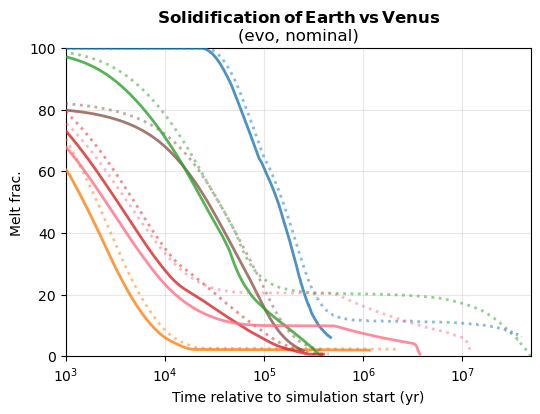

In [13]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

xkey = "t(yr)"
ykey = "phi(vol_frac)"
controls = ["evo", "nominal"]

xmax = 1e3
for m in models:
    print(m)

    if any([len(models_data[m][p]) == 0 for p in planets]):
        print("skipping model", m, "because of missing data")
        continue

    for p in planets:

        d = models_data[m][p]
        col = get_color(m)
        lw = 2

        if p == "earth":
            ls = "-"
            al = 0.8
            lbl = get_label(m)
        else:
            ls = "dotted"
            al = 0.5
            lbl = ""


        for case in d.keys():
            if np.all([param in case for param in controls]):

                x = d[case][xkey] 
                y = d[case][ykey] * 100

                xmax = max(xmax,np.amax(x))

                ax.plot(x, y, color=col, ls=ls, lw=lw, zorder=4, alpha=al, label=lbl)
                # if lbl != "":
                #     ax.annotate(lbl, (x.iloc[-1], y.iloc[-1]), color=col, fontsize=8, zorder=5, rotation=30, rotation_mode='anchor', ha='left')


# add vertical lines for ages of interest
for k, x in ages_yr.items():
    if x > xmax:
        continue
    ax.axvline(x, color="k", ls="--", lw=0.5, zorder=6)
    va = 'top'
    if k in ["Moon formed", "GOE early"]:
        va = 'bottom'
    ax.annotate(k, xy=(x, 80), ha="right", va=va, fontsize=8, rotation=90, rotation_mode='anchor')

ax.axvline(x=0, color="k", ls="-", lw=0.5)

ax.set_xscale("symlog", linthresh=1e3)
ax.set_xlabel("Time relative to simulation start (yr)")
ax.set_xlim(left=1e3, right=xmax)

ax.set_ylabel(get_label(ykey))
ax.set_ylim(0, 100)

ax.set_title(get_label(planet) + f" ({", ".join(controls)})")
ax.grid(alpha=0.3, zorder=-2)

title = r"$\bf Solidification\,of\,Earth\,vs\,Venus$" + "\n" + f"({', '.join(controls)})"
ax.set_title(title)

plt.show()

## Chemistry

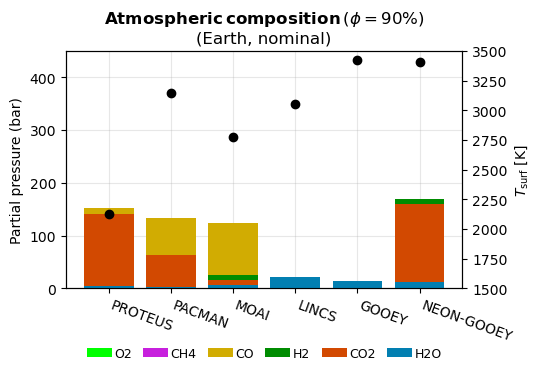

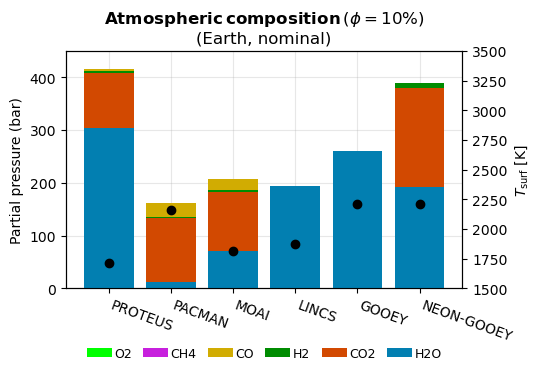

In [ ]:


def radar_factory(num_vars, frame='circle'):
    """
    Create a radar chart with `num_vars` Axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle', 'polygon'}
        Shape of frame surrounding Axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):

        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


radar_vars = ["p_surf(bar)"]
radar_vars.extend([f"p_{gas}(bar)" for gas in chili_gases])
N = len(models)

def plot_radar(case, phi_compare, legend=True):

    theta = radar_factory(N, frame='polygon')


    fig, ax = plt.subplots(1,1,subplot_kw=dict(projection='radar'))
    # fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)

    
    title = get_label(planet) + f" ({case})" + r", when $\phi=$" + f"{phi_compare*100:.0f}%"
    ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.1),
                    horizontalalignment='center', verticalalignment='center')
    
    case_data = []
    for m in models:
        dat = models_data[m]["earth"][case+"-evo"]
        vals = []

        idx = np.argmin(np.abs(dat["phi(vol_frac)"] - phi_compare))

        for var in radar_vars:
            try:
                val = dat[var].iloc[idx]
            except KeyError:
                val = 0
            if np.isfinite(val):
                vals.append(val)
            else:
                vals.append(0)
        case_data.append(vals)
    case_data = np.array(case_data).T
    
    dt = 50
    if np.amax(case_data) > 500:
        dt = 100
    ticks = np.arange(0,np.amax(case_data),dt)
    ax.set_rgrids(ticks)

    for k,d in zip(radar_vars,case_data):
        ax.plot(theta, d, color=get_color(k))
        ax.fill(theta, d, facecolor=get_color(k), alpha=0.3, label='_nolegend_')
    ax.set_varlabels([get_label(model) for model in models])

    # add legend relative to top-left plot
    if legend:
        ax.legend(radar_vars, bbox_to_anchor=(0.5, -0.05), loc='upper center',  ncols=4,
                    labelspacing=0.1, fontsize='small', )

    plt.show()

def plot_chem(case, planet, phi_compare):

    ykey_r = "T_surf(K)"

    fig, ax = plt.subplots(1,1, figsize=(5.5,4))
    axr = ax.twinx()

    ymax = 1
    xvals = []
    xlbls = []
    for m in models:
        dat = models_data[m][planet][case+"-evo"]

        idx = np.argmin(np.abs(dat["phi(vol_frac)"] - phi_compare))
        row = dat.iloc[idx]

        ybot = 0
        for gas in chili_gases:
            dy = row[f"p_{gas}(bar)"]
            
            c = get_color(gas)
            ax.bar(m, dy, bottom=ybot, color=c, zorder=3)
            ybot += dy

        axr.scatter(m, row[ykey_r], color="k", zorder=5)

        ymax = max(ymax, ybot+dy)
        xvals.append(m)
        xlbls.append(get_label(m))
        
    # legend
    for gas in chili_gases[::-1]:
        ax.bar(0, 0, color=get_color(gas), label=get_label(gas))

    ax.grid(zorder=-2, alpha=0.3)
    ax.set_ylabel("Partial pressure (bar)")
    ax.set_ylim(0, 450)
    ax.set_xticks(xvals, xlbls, rotation=-20, ha='left')
    ax.legend(ncols=len(chili_gases), loc='upper center', bbox_to_anchor=(0.5, -0.2), 
              fontsize=9, handletextpad=0.2, columnspacing=0.9, frameon=False)

    axr.set_ylim(1500, 3500)
    axr.set_ylabel(get_label(ykey_r))

    title = r"${\bf Atmospheric\,composition\,} (\phi=$" + f"{phi_compare*100:.0f}%" + ")\n" + f"({get_label(planet)}, {case})"
    ax.set_title(title)
    fig.tight_layout()

    plt.show()

plot_chem("nominal", "earth", 0.90)
plot_chem("nominal", "earth", 0.10)

# plot_radar("nominal", 0.10, legend=True)
# plot_radar("nominal", 0.90, legend=False)